# Notebook 5 - Análisis estadístico de la calidad del aire en la CDMX

Fuente de datos: [aire.cdmx.gob.mx](https://aire.cdmx.gob.mx) -> Datos -> Contaminante

Este notebook cubre:

1. Proceso de ETL (ingesta, limpieza, feature engineering) de los archivos "contaminantes_2024.csv", "contaminantes_2025.csv" y "contaminantes_2026.csv"
2. Cálculo de medidas de tendencia central (media, mediana, moda)
3. Cálculo de medidas de dispersión (varianza, desviación estándar)
4. Gráficas de las distribuciones de los contaminantes


## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
%matplotlib inline


## 1. Proceso de ETL

### 1.1. Ingesta

Cada CSV descargado del portal de aire.cdmx.gob.mx trae 9 renglones de metadatos
(ciudad, agencia de medición, periodo, versión, etc.) antes de la tabla de datos,
por lo que se omiten con "skiprows=9".

Además, la columna del valor medido se llama "value" en el archivo 2024 y "valor"
en los archivos 2025 y 2026, así que se homologa el nombre de la columna.


In [3]:
RUTAS = {
    2024: "contaminantes_2024.csv",
    2025: "contaminantes_2025.csv",
    2026: "contaminantes_2026.csv",
}


def cargar_csv_calidad_aire(ruta: str, anio_archivo: int) -> pd.DataFrame:
    """Carga un CSV de calidad del aire de la Red Automática de Monitoreo
    Atmosférico (RAMA) de la CDMX, omitiendo los metadatos iniciales y
    homologando el nombre de la columna del valor medido.
    """
    df = pd.read_csv(ruta, skiprows=9, encoding="utf-8")
    df = df.rename(columns={"value": "valor"})
    df["anio_archivo"] = anio_archivo
    return df


dfs = [cargar_csv_calidad_aire(ruta, anio) for anio, ruta in RUTAS.items()]
for anio, df_i in zip(RUTAS.keys(), dfs):
    print(f"{anio}: {df_i.shape[0]:,} renglones, columnas: {list(df_i.columns)}")


2024: 1,443,564 renglones, columnas: ['date', 'id_station', 'id_parameter', 'valor', 'unit', 'anio_archivo']
2025: 1,488,486 renglones, columnas: ['date', 'id_station', 'id_parameter', 'valor', 'unit', 'anio_archivo']
2026: 433,296 renglones, columnas: ['date', 'id_station', 'id_parameter', 'valor', 'unit', 'anio_archivo']


### 1.2. Unir los 3 CSV en un solo DataFrame

Los tres archivos comparten el mismo esquema ("date", "id_station", "id_parameter",
"valor", "unit"), así que se concatenan verticalmente en un único DataFrame
"df_calidad_aire" que se usará para todo el análisis.


In [4]:
df_calidad_aire = pd.concat(dfs, ignore_index=True)
print("Shape final:", df_calidad_aire.shape)
df_calidad_aire.head()


Shape final: (3365346, 6)


,date,id_station,id_parameter,valor,unit,anio_archivo
0,2024-01-01 01:00:00,ACO,CO,NaN,15.0,2024
1,2024-01-01 01:00:00,ACO,NO,NaN,1.0,2024
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.0,2024
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.0,2024
4,2024-01-01 01:00:00,ACO,O3,NaN,1.0,2024


### 1.3. Limpieza

Se convierte "date" a "datetime". Algunos registros de 2024 vienen sin hora (YYYY-MM-DD en vez de YYYY-MM-DD HH:MM:SS), por lo que se usa format="mixed" para poder parsear ambos formatos en la misma columna.

Se convierte "valor" a numérico ("NaN" cuando la estación no reportó lectura, lo cual es normal en datos de monitoreo atmosférico: fallas de sensor,mantenimiento, etc.).

Se revisan duplicados y valores nulos.


In [5]:
df_calidad_aire["date"] = pd.to_datetime(
    df_calidad_aire["date"], errors="coerce", format="mixed"
)
df_calidad_aire["valor"] = pd.to_numeric(df_calidad_aire["valor"], errors="coerce")
df_calidad_aire["id_parameter"] = df_calidad_aire["id_parameter"].astype("category")
df_calidad_aire["id_station"] = df_calidad_aire["id_station"].astype("category")

print("Duplicados exactos:", df_calidad_aire.duplicated().sum())
print("Fechas no parseables (NaT):", df_calidad_aire["date"].isna().sum())
print(
    "Lecturas nulas (NaN) en 'valor':",
    df_calidad_aire["valor"].isna().sum(),
    f"({df_calidad_aire['valor'].isna().mean() * 100:.1f}% del total)",
)


Duplicados exactos: 0
Fechas no parseables (NaT): 0
Lecturas nulas (NaN) en 'valor': 1368334 (40.7% del total)


In [6]:
# Eliminamos duplicados exactos, si los hubiera, y las filas cuya fecha
# no se pudo interpretar (no aportan al análisis de series de tiempo).
df_calidad_aire = df_calidad_aire.drop_duplicates()
df_calidad_aire = df_calidad_aire.dropna(subset=["date"])

# Las lecturas con 'valor' nulo (estación sin reporte) se conservan en el
# DataFrame general, pero se excluyen automáticamente de los cálculos
# estadísticos más abajo (pandas ignora NaN en mean/median/std/var).
print("Shape después de limpieza:", df_calidad_aire.shape)


Shape después de limpieza: (3365346, 6)


### 1.4. Feature engineering

A partir de "date" se derivan columnas útiles para el análisis: año, mes, día,
hora y día de la semana.


In [7]:
df_calidad_aire["anio"] = df_calidad_aire["date"].dt.year
df_calidad_aire["mes"] = df_calidad_aire["date"].dt.month
df_calidad_aire["dia"] = df_calidad_aire["date"].dt.day
df_calidad_aire["hora"] = df_calidad_aire["date"].dt.hour
df_calidad_aire["dia_semana"] = df_calidad_aire["date"].dt.day_name()

df_calidad_aire.head()


,date,id_station,id_parameter,valor,unit,anio_archivo,anio,mes,dia,hora,dia_semana
0,2024-01-01 01:00:00,ACO,CO,NaN,15.0,2024,2024,1,1,1,Monday
1,2024-01-01 01:00:00,ACO,NO,NaN,1.0,2024,2024,1,1,1,Monday
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.0,2024,2024,1,1,1,Monday
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.0,2024,2024,1,1,1,Monday
4,2024-01-01 01:00:00,ACO,O3,NaN,1.0,2024,2024,1,1,1,Monday


In [8]:
df_calidad_aire.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3365346 entries, 0 to 3365345
Data columns (total 11 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[ns]
 1   id_station    category      
 2   id_parameter  category      
 3   valor         float64       
 4   unit          float64       
 5   anio_archivo  int64         
 6   anio          int32         
 7   mes           int32         
 8   dia           int32         
 9   hora          int32         
 10  dia_semana    object        
dtypes: category(2), datetime64[ns](1), float64(2), int32(4), int64(1), object(1)
memory usage: 186.1+ MB


## 2. Medidas de tendencia central

Media, mediana y moda del valor medido ("valor") por contaminante
("id_parameter"), considerando los tres años juntos.


In [9]:
medidas_tendencia_central = df_calidad_aire.groupby("id_parameter", observed=True)["valor"].agg(
    media="mean",
    mediana="median",
    moda=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
).round(3)

medidas_tendencia_central


,media,mediana,moda
id_parameter,,,
CO,0.511,0.4,0.25
NO,12.886,3.0,1.00
NO2,23.295,21.0,14.00
NOX,36.511,25.0,14.00
O3,35.183,28.0,2.00
PM10,44.406,39.0,37.00
PM2.5,21.592,20.0,16.00
PMCO,19.483,16.0,7.00
SO2,2.900,1.0,1.00


Lo mismo, pero desglosado por año, para ver si cambia el comportamiento entre 2024, 2025 y 2026:

In [10]:
medidas_tendencia_por_anio = (
    df_calidad_aire.groupby(["id_parameter", "anio"], observed=True)["valor"]
    .agg(
        media="mean",
        mediana="median",
        moda=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    )
    .round(3)
)
medidas_tendencia_por_anio


media  mediana   moda
id_parameter anio                        
CO           2024   0.474     0.35   0.25
             2025   0.484     0.40   0.28
             2026   0.789     0.64   0.37
NO           2024  12.974     3.00   1.00
             2025  11.095     3.00   1.00
             2026  20.405     4.00   1.00
NO2          2024  23.838    21.00  11.00
             2025  21.504    19.00  15.00
             2026  29.539    27.00  25.00
NOX          2024  36.698    24.00  14.00
             2025  33.322    24.00  14.00
             2026  49.764    33.00  22.00
O3           2024  36.270    30.00   2.00
             2025  34.968    28.00   2.00
             2026  31.578    23.00   3.00
PM10         2024  46.262    41.00  37.00
             2025  40.956    36.00  30.00
             2026  52.091    46.00  37.00
PM2.5        2024  21.849    20.00  18.00
             2025  20.422    19.00  16.00
             2026  25.612    23.00  22.00
PMCO         2024  21.106    18.00  15.00
             2025  17.571    14.00   7.00
             2026  19.947    16.00   7.00
SO2          2024   2.515     1.00   1.00
             2025   2.300     1.00   1.00
             2026   7.004     3.00   2.00

## 3. Medidas de dispersión

Varianza y desviación estándar del valor medido por contaminante (además de
mínimo y máximo, útiles para detectar outliers).


In [11]:
medidas_dispersion = df_calidad_aire.groupby("id_parameter", observed=True)["valor"].agg(
    varianza="var",
    desviacion_estandar="std",
    minimo="min",
    maximo="max",
).round(3)

medidas_dispersion


,varianza,desviacion_estandar,minimo,maximo
id_parameter,,,,
CO,0.178,0.422,0.0,6.09
NO,785.879,28.034,0.0,525.00
NO2,198.298,14.082,0.0,136.00
NOX,1369.531,37.007,0.0,575.00
O3,859.536,29.318,-1.0,187.00
PM10,853.956,29.223,0.0,652.00
PM2.5,180.330,13.429,0.0,324.00
PMCO,231.233,15.206,0.0,304.00
SO2,33.847,5.818,0.0,212.00


In [12]:
medidas_dispersion_por_anio = (
    df_calidad_aire.groupby(["id_parameter", "anio"], observed=True)["valor"]
    .agg(varianza="var", desviacion_estandar="std")
    .round(3)
)
medidas_dispersion_por_anio


varianza  desviacion_estandar
id_parameter anio                               
CO           2024     0.180                0.424
             2025     0.131                0.362
             2026     0.310                0.557
NO           2024   842.221               29.021
             2025   571.933               23.915
             2026  1436.679               37.904
NO2          2024   214.171               14.635
             2025   160.020               12.650
             2026   259.322               16.103
NOX          2024  1488.355               38.579
             2025  1013.637               31.838
             2026  2250.228               47.437
O3           2024   875.676               29.592
             2025   841.671               29.012
             2026   854.629               29.234
PM10         2024   893.578               29.893
             2025   733.206               27.078
             2026  1100.082               33.167
PM2.5        2024   187.032               13.676
             2025   142.524               11.938
             2026   294.856               17.171
PMCO         2024   227.075               15.069
             2025   230.689               15.188
             2026   224.966               14.999
SO2          2024    26.733                5.170
             2025    13.046                3.612
             2026   132.455               11.509

## 4. Graficar distribuciones

### 4.1. Histogramas por contaminante

Un histograma por cada contaminante, mostrando la forma de su distribución.


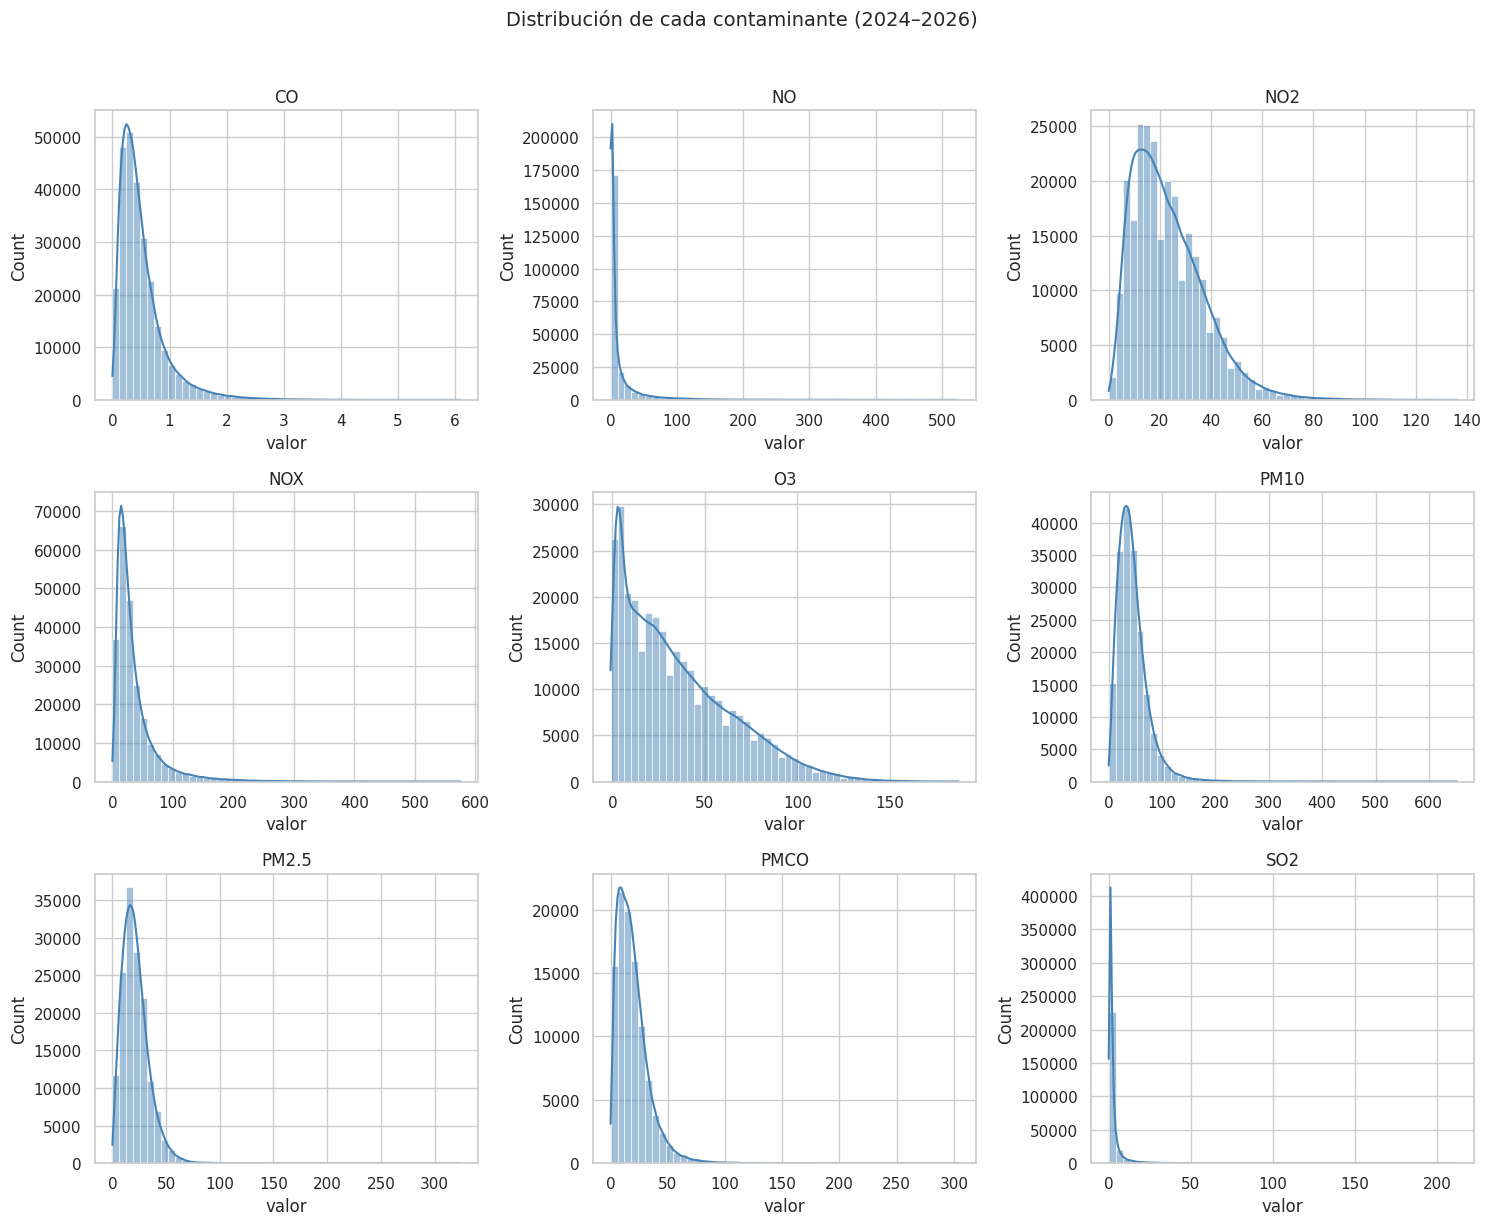

In [13]:
parametros = df_calidad_aire["id_parameter"].cat.categories
n = len(parametros)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for ax, parametro in zip(axes, parametros):
    datos = df_calidad_aire.loc[
        df_calidad_aire["id_parameter"] == parametro, "valor"
    ].dropna()
    sns.histplot(datos, bins=50, kde=True, ax=ax, color="steelblue")
    ax.set_title(parametro)
    ax.set_xlabel("valor")

# Ocultar ejes sobrantes si el número de contaminantes no llena la cuadrícula
for ax in axes[n:]:
    ax.axis("off")

plt.suptitle("Distribución de cada contaminante (2024–2026)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 4.2. Boxplots por contaminante, comparando 2024, 2025 y 2026

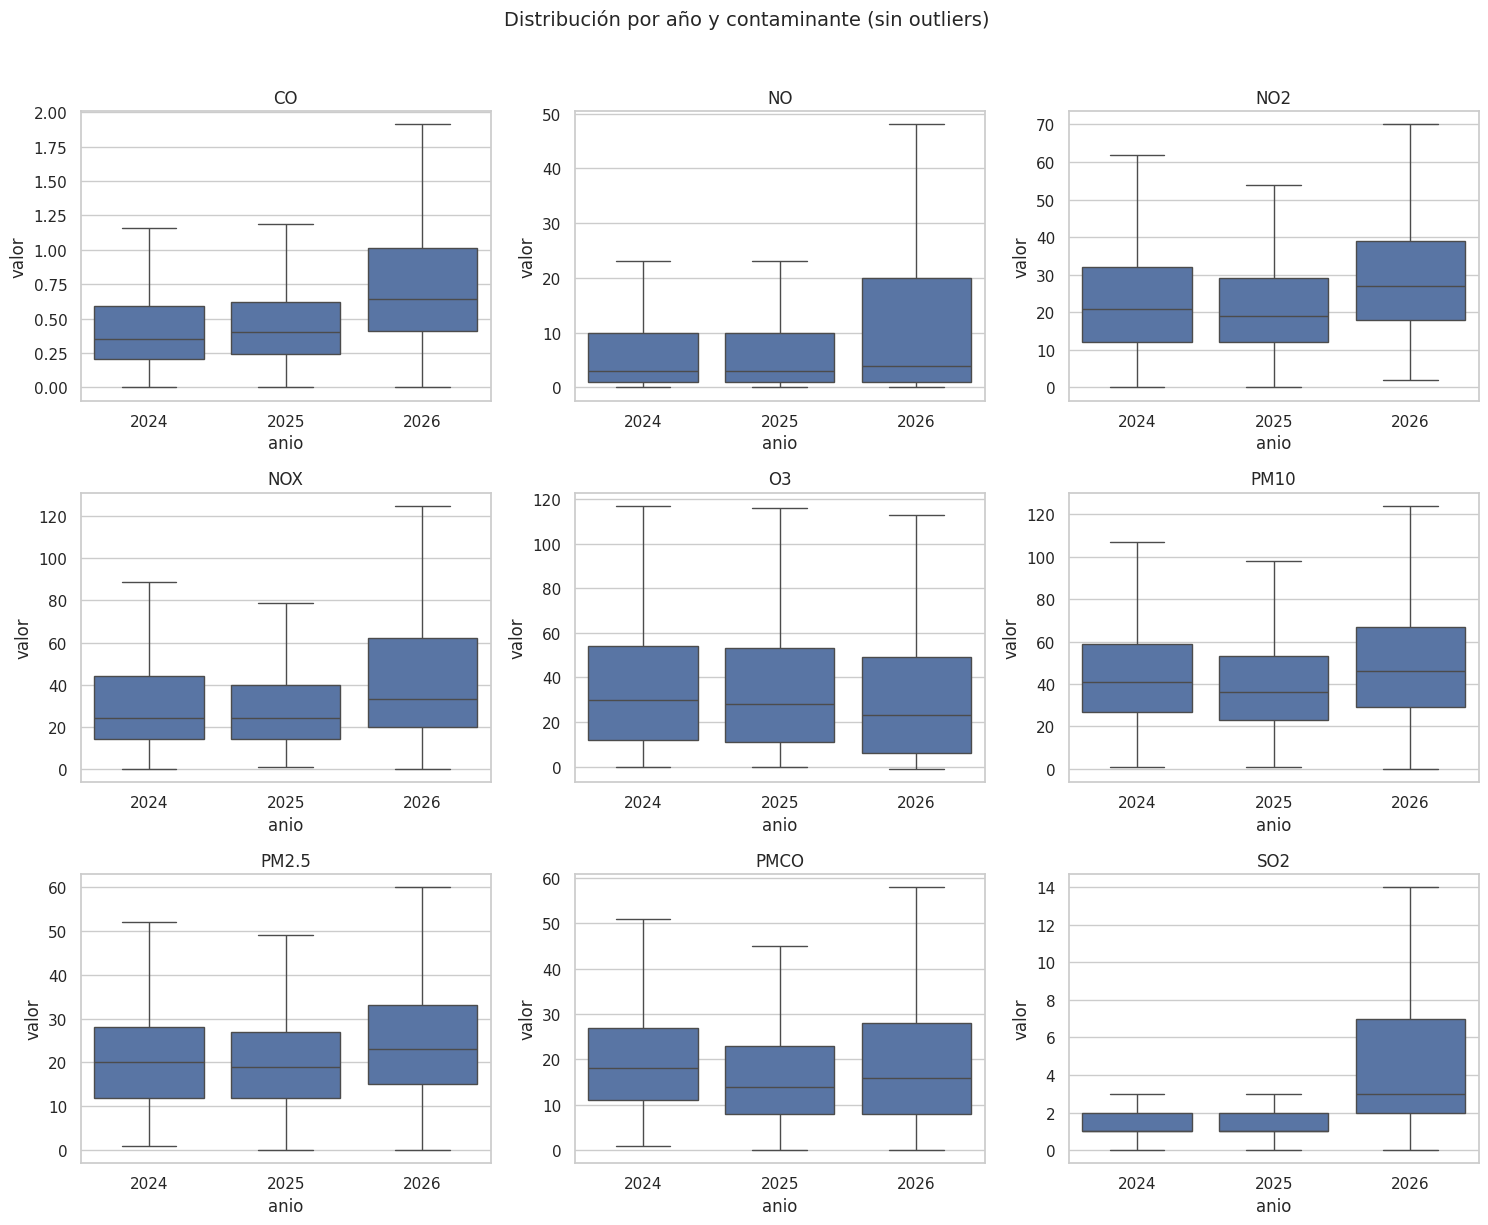

In [14]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for ax, parametro in zip(axes, parametros):
    subset = df_calidad_aire[df_calidad_aire["id_parameter"] == parametro]
    sns.boxplot(data=subset, x="anio", y="valor", ax=ax, showfliers=False)
    ax.set_title(parametro)

for ax in axes[n:]:
    ax.axis("off")

plt.suptitle("Distribución por año y contaminante (sin outliers)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 4.3. Distribución general de todos los contaminantes (violin plot)

Comparación conjunta, en escala logarítmica en el eje "y" porque las magnitudes entre contaminantes son muy distintas.


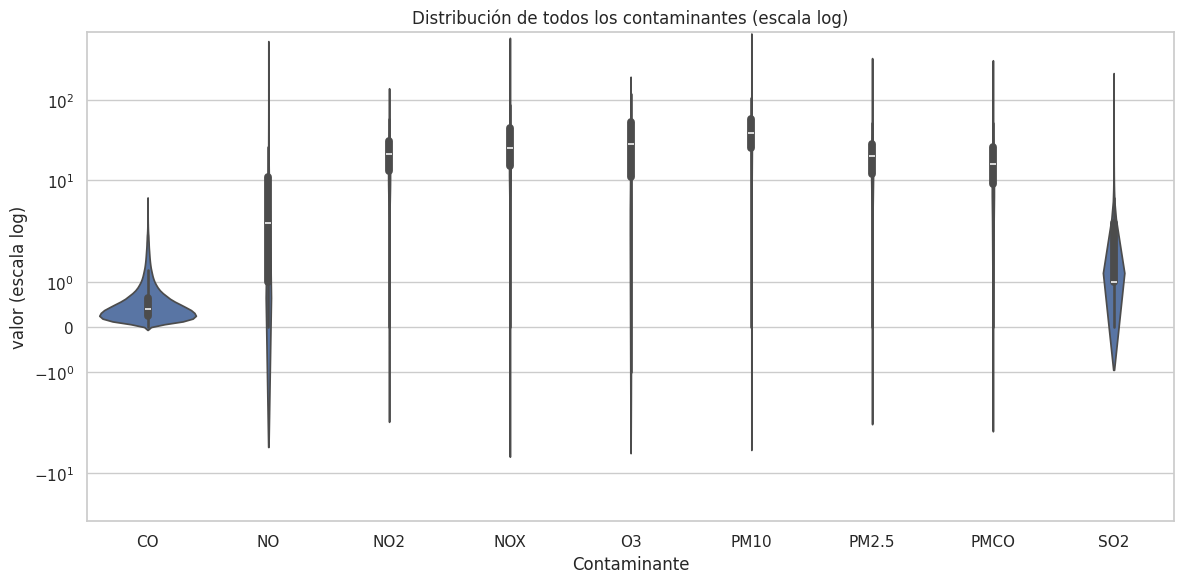

In [15]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_calidad_aire,
    x="id_parameter",
    y="valor",
    order=sorted(parametros),
)
plt.yscale("symlog")
plt.title("Distribución de todos los contaminantes (escala log)")
plt.xlabel("Contaminante")
plt.ylabel("valor (escala log)")
plt.tight_layout()
plt.show()


## 5. Conclusiones

A partir de las tablas y gráficas anteriores se puede resumir el
comportamiento estadístico de cada contaminante (tendencia central,
dispersión y forma de la distribución) y compararlo entre 2024, 2025 y lo
que va de 2026.
